In [2]:
import sys

In [3]:
print(sys.executable)

/Users/rafalrucki/Desktop/analiza-rynku-pracy-ml/.venv/bin/python


In [4]:
import pandas as pd
import numpy as np

# Wczytaj dane (katalog wyżej)
df = pd.read_csv('../data/nfj_jobs_clean.csv')
print(f"✓ Wczytano {len(df)} rekordów")
print(f"Kolumny: {list(df.columns)}")
df.head()

✓ Wczytano 123 rekordów
Kolumny: ['title', 'city', 'level', 'category', 'salary_from', 'salary_to', 'salary_avg', 'currency']


,title,city,level,category,salary_from,salary_to,salary_avg,currency
0,Python Developer,Kraków,Mid,backend,16800.0,18900.0,17850.0,PLN
1,Senior Python Developer (m/f/d),Remote,Senior,backend,22000.0,26000.0,24000.0,PLN
2,Senior Python Developer (m/f/d),Remote/Unknown,Senior,backend,22000.0,26000.0,24000.0,PLN
3,Staff Python Engineer,Warsaw,Expert,backend,40000.0,52000.0,46000.0,PLN
4,Team Lead (Python/AWS/React),Remote,Senior,backend,30240.0,42000.0,36120.0,PLN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        123 non-null    str    
 1   city         123 non-null    str    
 2   level        123 non-null    str    
 3   category     123 non-null    str    
 4   salary_from  123 non-null    float64
 5   salary_to    123 non-null    float64
 6   salary_avg   123 non-null    float64
 7   currency     123 non-null    str    
dtypes: float64(3), str(5)
memory usage: 14.4 KB


In [6]:
print(df.shape)

(123, 8)


In [7]:
df

,title,city,level,category,salary_from,salary_to,salary_avg,currency
0,Python Developer,Kraków,Mid,backend,16800.0,18900.0,17850.0,PLN
1,Senior Python Developer (m/f/d),Remote,Senior,backend,22000.0,26000.0,24000.0,PLN
2,Senior Python Developer (m/f/d),Remote/Unknown,Senior,backend,22000.0,26000.0,24000.0,PLN
3,Staff Python Engineer,Warsaw,Expert,backend,40000.0,52000.0,46000.0,PLN
4,Team Lead (Python/AWS/React),Remote,Senior,backend,30240.0,42000.0,36120.0,PLN
...,...,...,...,...,...,...,...,...
118,Senior Software Development Engineer,Warszawa,Senior,backend,30240.0,33600.0,31920.0,PLN
119,Senior Software Development Engineer,Remote/Unknown,Senior,backend,30240.0,33600.0,31920.0,PLN
120,Staff Engineer,Gdańsk,Expert,fullstack,35000.0,45000.0,40000.0,PLN
121,Expert Fullstack Django & Angular Developer,Gdańsk,Mid,fullstack,21168.0,24024.0,22596.0,PLN


In [8]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Ekstrakcja technologii/frameworków
technologies = ['python', 'java', 'javascript', 'react', 'django', 
                'fastapi', 'flask', 'sql', 'aws', 'docker', 'kubernetes']

# Dla każdej technologii → binary feature (0/1)
df['has_python'] = df['title'].str.lower().str.contains('python').astype(int)
df['has_react'] = df['title'].str.lower().str.contains('react').astype(int)
# itd...

# Dodatkowe cechy z title:
df['title_length'] = df['title'].str.len()  # długość tytułu
df['word_count'] = df['title'].str.split().str.len()  # liczba słów

In [10]:
# Ordinal encoding (bo jest naturalna kolejność)
level_mapping = {'trainee': 0, 'junior': 1, 'mid': 2, 'senior': 3, 'lead': 4, 'expert': 5}
df['level_encoded'] = df['level'].str.lower().map(level_mapping)

# One-hot encoding (alternatywa)
df_level_ohe = pd.get_dummies(df['level'], prefix='level')

In [11]:
# Binary: czy Warszawa (typowo wyższe płace)
df['is_warsaw'] = (df['city'].str.lower() == 'warszawa').astype(int)

# Binary: czy remote
df['is_remote'] = df['city'].str.lower().str.contains('remote|zdalna').astype(int)

# Top 5 miast + "inne"
top_cities = df['city'].value_counts().head(5).index
df['city_grouped'] = df['city'].apply(lambda x: x if x in top_cities else 'Other')
df_city_ohe = pd.get_dummies(df['city_grouped'], prefix='city')

In [12]:
# One-hot encoding kategorii
df_category_ohe = pd.get_dummies(df['category'], prefix='category')

In [13]:
# Szerokość widełek (może oznaczać elastyczność/niepewność)
df['salary_range'] = df['salary_to'] - df['salary_from']

# Czy ma zdefiniowane widełki
df['has_salary'] = df['salary_avg'].notna().astype(int)

In [14]:
# Wczytaj dane
df

,title,city,level,category,salary_from,salary_to,salary_avg,currency,has_python,has_react,title_length,word_count,level_encoded,is_warsaw,is_remote,city_grouped,salary_range,has_salary
0,Python Developer,Kraków,Mid,backend,16800.0,18900.0,17850.0,PLN,1,0,16,2,2,0,0,Kraków,2100.0,1
1,Senior Python Developer (m/f/d),Remote,Senior,backend,22000.0,26000.0,24000.0,PLN,1,0,31,4,3,0,1,Remote,4000.0,1
2,Senior Python Developer (m/f/d),Remote/Unknown,Senior,backend,22000.0,26000.0,24000.0,PLN,1,0,31,4,3,0,1,Remote/Unknown,4000.0,1
3,Staff Python Engineer,Warsaw,Expert,backend,40000.0,52000.0,46000.0,PLN,1,0,22,3,5,0,0,Other,12000.0,1
4,Team Lead (Python/AWS/React),Remote,Senior,backend,30240.0,42000.0,36120.0,PLN,1,1,28,3,3,0,1,Remote,11760.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,Senior Software Development Engineer,Warszawa,Senior,backend,30240.0,33600.0,31920.0,PLN,0,0,36,4,3,1,0,Warszawa,3360.0,1
119,Senior Software Development Engineer,Remote/Unknown,Senior,backend,30240.0,33600.0,31920.0,PLN,0,0,36,4,3,0,1,Remote/Unknown,3360.0,1
120,Staff Engineer,Gdańsk,Expert,fullstack,35000.0,45000.0,40000.0,PLN,0,0,14,2,5,0,0,Other,10000.0,1
121,Expert Fullstack Django & Angular Developer,Gdańsk,Mid,fullstack,21168.0,24024.0,22596.0,PLN,0,0,43,6,2,0,0,Other,2856.0,1


In [15]:
print(f"Dane wejściowe: {df.shape}")

Dane wejściowe: (123, 18)


In [16]:
# Lista kluczowych technologii do wykrycia
technologies = [
    'python', 'java', 'javascript', 'typescript', 'php', 'ruby', 'go', 'rust', 'scala', 'kotlin',
    'react', 'angular', 'vue', 'django', 'flask', 'fastapi', 'spring', 'node',
    'sql', 'nosql', 'mongodb', 'postgresql', 'mysql', 'redis',
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'terraform', 'jenkins',
    'machine learning', 'data science', 'deep learning', 'tensorflow', 'pytorch'
]

# Utwórz kolumny binarne dla każdej technologii
for tech in technologies:
    col_name = f'tech_{tech.replace(" ", "_")}'
    df[col_name] = df['title'].str.lower().str.contains(tech, na=False, regex=False).astype(int)

print(f"Utworzono {len(technologies)} cech technologicznych")

Utworzono 36 cech technologicznych


In [17]:
# Specjalne przypadki wymagające regex
special_techs = {
    'cplus': r'c\+\+',
    'csharp': r'c#',
    'dotnet': r'\.net'
}

for tech_name, tech_pattern in special_techs.items():
    col_name = f'tech_{tech_name}'
    df[col_name] = df['title'].str.lower().str.contains(tech_pattern, na=False, regex=True).astype(int)

print(f"Dodano {len(special_techs)} specjalnych technologii")

Dodano 3 specjalnych technologii


In [18]:
# Utwórz kolumny binarne dla każdej technologii
for tech in technologies:
    col_name = f'tech_{tech.replace(" ", "_").replace("#", "sharp").replace("+", "plus")}'
    df[col_name] = df['title'].str.lower().str.contains(tech, na=False).astype(int)

In [19]:
# Długość tytułu i liczba słów
df['title_length'] = df['title'].str.len()
df['title_word_count'] = df['title'].str.split().str.len()

# Liczba wykrytych technologii
tech_cols = [col for col in df.columns if col.startswith('tech_')]
df['tech_count'] = df[tech_cols].sum(axis=1)

print(f"Łącznie {len(tech_cols)} cech technologicznych")
print(f"Przykład tech_count: min={df['tech_count'].min()}, max={df['tech_count'].max()}")

Łącznie 39 cech technologicznych
Przykład tech_count: min=0, max=4


In [20]:
# Ordinal encoding poziomów doświadczenia
level_mapping = {
    'trainee': 0,
    'junior': 1, 
    'mid': 2,
    'senior': 3,
    'lead': 4,
    'expert': 5,
    'principal': 6
}

df['level_clean'] = df['level'].str.lower().str.strip()
df['level_encoded'] = df['level_clean'].map(level_mapping)

# Wypełnij brakujące wartości medianą (mid=2)
df['level_encoded'] = df['level_encoded'].fillna(2)

print(f"Level encoding - unique values: {sorted(df['level_encoded'].unique())}")
print(f"Rozkład poziomów:\n{df['level_encoded'].value_counts().sort_index()}")

Level encoding - unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Rozkład poziomów:
level_encoded
1      4
2     15
3    100
5      4
Name: count, dtype: int64


In [21]:
# Binary features dla miasta
df['is_warsaw'] = df['city'].str.lower().str.contains('warszawa|warsaw', na=False, regex=True).astype(int)
df['is_remote'] = df['city'].str.lower().str.contains('remote|zdalna|zdalnie', na=False, regex=True).astype(int)

# Top 5 miast (reszta = Other)
top_cities = df['city'].value_counts().head(5).index.tolist()
df['city_grouped'] = df['city'].apply(lambda x: x if x in top_cities else 'Other')

print(f"✓ Top 5 miast: {top_cities}")
print(f"✓ Warszawa: {df['is_warsaw'].sum()} ofert")
print(f"✓ Remote: {df['is_remote'].sum()} ofert")

✓ Top 5 miast: ['Remote', 'Remote/Unknown', 'Warszawa', 'Kraków', 'Wrocław']
✓ Warszawa: 21 ofert
✓ Remote: 52 ofert


In [22]:
# One-hot encoding dla miast
df_city = pd.get_dummies(df['city_grouped'], prefix='city', drop_first=True)
df = pd.concat([df, df_city], axis=1)

print(f"✓ City one-hot: {df_city.shape[1]} kolumn")
print(f"Kolumny: {list(df_city.columns)}")

✓ City one-hot: 5 kolumn
Kolumny: ['city_Other', 'city_Remote', 'city_Remote/Unknown', 'city_Warszawa', 'city_Wrocław']


In [23]:
# One-hot encoding kategorii
df_category = pd.get_dummies(df['category'], prefix='category', drop_first=True)
df = pd.concat([df, df_category], axis=1)

print(f"✓ Category one-hot: {df_category.shape[1]} kolumn")
print(f"Kolumny: {list(df_category.columns)}")

✓ Category one-hot: 1 kolumn
Kolumny: ['category_fullstack']


In [24]:
# Szerokość widełek płacowych
df['salary_range'] = df['salary_to'] - df['salary_from']
df['salary_range'] = df['salary_range'].fillna(0)

# Czy ma zdefiniowane wynagrodzenie
df['has_salary'] = df['salary_avg'].notna().astype(int)

print(f"✓ Salary features")
print(f"Średnia szerokość widełek: {df['salary_range'].mean():.0f} PLN")
print(f"Oferty z wynagrodzeniem: {df['has_salary'].sum()} / {len(df)}")

✓ Salary features
Średnia szerokość widełek: 6793 PLN
Oferty z wynagrodzeniem: 123 / 123


In [25]:
print("\n" + "="*60)
print("FEATURE ENGINEERING - PODSUMOWANIE")
print("="*60)
print(f"Liczba rekordów: {len(df)}")
print(f"Liczba kolumn TERAZ: {df.shape[1]}")

print(f"\nNowe cechy:")
tech_cols = [c for c in df.columns if c.startswith('tech_')]
print(f"  - Technologie: {len(tech_cols)}")
print(f"  - Level: 1 (encoded)")
print(f"  - City: {len([c for c in df.columns if c.startswith('city_')]) + 2}")
print(f"  - Category: {len([c for c in df.columns if c.startswith('category_')])}")
print(f"  - Salary: 2 (range, has_salary)")
print(f"  - Title meta: 3 (length, word_count, tech_count)")

# Podgląd
display_cols = ['title', 'level_encoded', 'is_warsaw', 'is_remote', 'tech_count', 'salary_avg']
df[display_cols].head(10)


FEATURE ENGINEERING - PODSUMOWANIE
Liczba rekordów: 123
Liczba kolumn TERAZ: 66

Nowe cechy:
  - Technologie: 40
  - Level: 1 (encoded)
  - City: 8
  - Category: 1
  - Salary: 2 (range, has_salary)
  - Title meta: 3 (length, word_count, tech_count)


,title,level_encoded,is_warsaw,is_remote,tech_count,salary_avg
0,Python Developer,2,0,0,1,17850.0
1,Senior Python Developer (m/f/d),3,0,1,1,24000.0
2,Senior Python Developer (m/f/d),3,0,1,1,24000.0
3,Staff Python Engineer,5,1,0,1,46000.0
4,Team Lead (Python/AWS/React),3,0,1,3,36120.0
5,Team Lead (Python/AWS/React),3,0,0,3,36120.0
6,Team Lead (Python/AWS/React),3,1,0,3,36120.0
7,Team Lead (Python/AWS/React),3,0,0,3,36120.0
8,Team Lead (Python/AWS/React),3,0,0,3,36120.0
9,Team Lead (Python/AWS/React),3,0,0,3,36120.0


In [ ]:
# Usuń wiersze bez salary_avg
df_model = df[df['salary_avg'].notna()].copy()
print(f"Dane do modelowania: {len(df_model)} rekordów (usunięto {len(df) - len(df_model)} bez salary_avg)")

# Wybierz cechy numeryczne do modelu
# Uwaga: salary_range celowo wykluczone — jest pochodną salary_from/salary_to,
# co powoduje wyciek danych (data leakage) i zaburza przewidywania dla juniorów.
feature_cols = (
    tech_cols + 
    ['level_encoded', 'is_warsaw', 'is_remote', 'title_length', 
     'title_word_count', 'tech_count'] +
    [c for c in df.columns if c.startswith('city_')] +
    [c for c in df.columns if c.startswith('category_')]
)

X = df_model[feature_cols]
y = df_model['salary_avg']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Brakujące wartości w X: {X.isnull().sum().sum()}")
print(f"\nPrzykład X:")
X.head(3)

In [27]:
import os

# Upewnij się że katalog istnieje
os.makedirs('../data', exist_ok=True)

# Zapisz
df_model.to_csv('../data/nfj_jobs_features.csv', index=False)
X.to_csv('../data/X_features.csv', index=False)
y.to_csv('../data/y_target.csv', index=False)

print("✓ Zapisano:")
print("  - ../data/nfj_jobs_features.csv (pełny zbiór)")
print("  - ../data/X_features.csv (features)")
print("  - ../data/y_target.csv (target)")

✓ Zapisano:
  - ../data/nfj_jobs_features.csv (pełny zbiór)
  - ../data/X_features.csv (features)
  - ../data/y_target.csv (target)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Sklearn - metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Biblioteki załadowane")

✓ Biblioteki załadowane


In [29]:
# Wczytaj X i y
X = pd.read_csv('../data/X_features.csv')
y = pd.read_csv('../data/y_target.csv').squeeze()  # squeeze zamienia DataFrame na Series

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nPierwsze 3 wiersze X:")
print(X.head(3))
print(f"\nPierwsze 5 wartości y: {y.head().values}")

X shape: (123, 54)
y shape: (123,)

Pierwsze 3 wiersze X:
   tech_python  tech_java  tech_javascript  tech_typescript  tech_php  \
0            1          0                0                0         0   
1            1          0                0                0         0   
2            1          0                0                0         0   

   tech_ruby  tech_go  tech_rust  tech_scala  tech_kotlin  ...  \
0          0        0          0           0            0  ...   
1          0        0          0           0            0  ...   
2          0        0          0           0            0  ...   

   title_word_count  tech_count.1  salary_range    city_grouped  city_Other  \
0                 2             1        2100.0          Kraków       False   
1                 4             1        4000.0          Remote       False   
2                 4             1        4000.0  Remote/Unknown       False   

   city_Remote  city_Remote/Unknown  city_Warszawa  city_Wrocław  \

In [30]:
# Podział danych 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nRozkład target w train:")
print(f"  Mean: {y_train.mean():.0f} PLN")
print(f"  Median: {y_train.median():.0f} PLN")
print(f"  Std: {y_train.std():.0f} PLN")

Train set: 98 samples
Test set: 25 samples

Rozkład target w train:
  Mean: 24732 PLN
  Median: 24360 PLN
  Std: 6910 PLN


In [31]:
# Baseline: przewiduj średnią
baseline_pred = np.full(len(y_test), y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("="*60)
print("BASELINE MODEL - Przewiduj zawsze średnią z train")
print("="*60)
print(f"MAE:  {baseline_mae:.0f} PLN")
print(f"RMSE: {baseline_rmse:.0f} PLN")
print(f"R²:   {baseline_r2:.4f}")
print("\n👉 Każdy model MUSI być lepszy niż baseline!")

BASELINE MODEL - Przewiduj zawsze średnią z train
MAE:  4423 PLN
RMSE: 5725 PLN
R²:   -0.0085

👉 Każdy model MUSI być lepszy niż baseline!


In [32]:
# Sprawdź typy danych w X
print("Typy danych w X:")
print(X.dtypes.value_counts())
print("\nNienumeryczne kolumny:")
print(X.select_dtypes(exclude=[np.number]).columns.tolist())

# Wybierz TYLKO numeryczne kolumny
X_numeric = X.select_dtypes(include=[np.number])

print(f"\n✓ Oryginalne X: {X.shape[1]} kolumn")
print(f"✓ Numeryczne X: {X_numeric.shape[1]} kolumn")

# Zaktualizuj train/test split na numerycznych danych
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, 
    test_size=0.2, 
    random_state=42
)

print(f"\n✓ Train set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")

Typy danych w X:
int64      46
bool        6
float64     1
str         1
Name: count, dtype: int64

Nienumeryczne kolumny:
['city_grouped', 'city_Other', 'city_Remote', 'city_Remote/Unknown', 'city_Warszawa', 'city_Wrocław', 'category_fullstack']

✓ Oryginalne X: 54 kolumn
✓ Numeryczne X: 47 kolumn

✓ Train set: (98, 47)
✓ Test set: (25, 47)


In [33]:
# Skalowanie numerycznych danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Dane przeskalowane (StandardScaler)")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Przykład: przed i po skalowaniu
print(f"\nPrzykład przed skalowaniem (pierwsza cecha):")
print(f"  Mean: {X_train.iloc[:, 0].mean():.2f}")
print(f"  Std: {X_train.iloc[:, 0].std():.2f}")

print(f"\nPo skalowaniu (pierwsza cecha):")
print(f"  Mean: {X_train_scaled[:, 0].mean():.2f}")
print(f"  Std: {X_train_scaled[:, 0].std():.2f}")

✓ Dane przeskalowane (StandardScaler)
X_train_scaled shape: (98, 47)
X_test_scaled shape: (25, 47)

Przykład przed skalowaniem (pierwsza cecha):
  Mean: 0.94
  Std: 0.24

Po skalowaniu (pierwsza cecha):
  Mean: -0.00
  Std: 1.00


In [34]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name="Model"):
    """Trenuje model i zwraca metryki"""
    
    # Trenowanie
    model.fit(X_tr, y_tr)
    
    # Predykcje
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    # Metryki - Train
    train_mae = mean_absolute_error(y_tr, y_pred_train)
    train_rmse = np.sqrt(mean_squared_error(y_tr, y_pred_train))
    train_r2 = r2_score(y_tr, y_pred_train)
    
    # Metryki - Test
    test_mae = mean_absolute_error(y_te, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred_test))
    test_r2 = r2_score(y_te, y_pred_test)
    
    return {
        'model_name': model_name,
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'model': model,
        'predictions': y_pred_test
    }

print("✓ Funkcja evaluate_model() gotowa")

✓ Funkcja evaluate_model() gotowa


In [35]:
# Definicja modeli do porównania
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Lasso (alpha=10)': Lasso(alpha=10),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5)
}

# Lista wyników
results = []

print("="*60)
print("TRENOWANIE MODELI")
print("="*60)

for name, model in models.items():
    print(f"\n🔄 Trenuję: {name}...")
    
    # Modele wymagające skalowania
    if name in ['Ridge (alpha=10)', 'Lasso (alpha=10)', 'KNN (k=5)']:
        result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    else:
        result = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    
    results.append(result)
    
    print(f"  Train MAE: {result['train_mae']:.0f} PLN | Test MAE: {result['test_mae']:.0f} PLN")
    print(f"  Train R²:  {result['train_r2']:.4f}   | Test R²:  {result['test_r2']:.4f}")

print("\n✓ Wszystkie modele wytrenowane!")

TRENOWANIE MODELI

🔄 Trenuję: Linear Regression...
  Train MAE: 2871 PLN | Test MAE: 2698 PLN
  Train R²:  0.6984   | Test R²:  0.6291

🔄 Trenuję: Ridge (alpha=10)...
  Train MAE: 2972 PLN | Test MAE: 2801 PLN
  Train R²:  0.6873   | Test R²:  0.6254

🔄 Trenuję: Lasso (alpha=10)...
  Train MAE: 2876 PLN | Test MAE: 2701 PLN
  Train R²:  0.6983   | Test R²:  0.6307

🔄 Trenuję: Decision Tree...
  Train MAE: 144 PLN | Test MAE: 897 PLN
  Train R²:  0.9974   | Test R²:  0.6967

🔄 Trenuję: Random Forest...
  Train MAE: 726 PLN | Test MAE: 1566 PLN
  Train R²:  0.9673   | Test R²:  0.6760

🔄 Trenuję: Gradient Boosting...
  Train MAE: 35 PLN | Test MAE: 1176 PLN
  Train R²:  0.9999   | Test R²:  0.6111

🔄 Trenuję: KNN (k=5)...
  Train MAE: 2684 PLN | Test MAE: 2588 PLN
  Train R²:  0.6346   | Test R²:  0.4988

✓ Wszystkie modele wytrenowane!


In [36]:
# DataFrame z wynikami
results_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Train MAE': r['train_mae'],
        'Test MAE': r['test_mae'],
        'Train R²': r['train_r2'],
        'Test R²': r['test_r2'],
        'Overfit': r['train_r2'] - r['test_r2']  # różnica = overfitting
    }
    for r in results
])

# Sortuj po Test MAE (niższy = lepszy)
results_df = results_df.sort_values('Test MAE')

print("\n" + "="*80)
print("PORÓWNANIE MODELI")
print("="*80)
print(results_df.to_string(index=False))

# Najlepszy model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 NAJLEPSZY MODEL: {best_model_name}")
print(f"   Test MAE: {results_df.iloc[0]['Test MAE']:.0f} PLN")
print(f"   Test R²:  {results_df.iloc[0]['Test R²']:.4f}")


PORÓWNANIE MODELI
            Model   Train MAE    Test MAE  Train R²  Test R²  Overfit
    Decision Tree  143.591837  896.960000  0.997359 0.696745 0.300615
Gradient Boosting   35.245716 1175.817269  0.999929 0.611115 0.388814
    Random Forest  726.217000 1566.307973  0.967317 0.675985 0.291332
        KNN (k=5) 2684.248980 2588.156000  0.634565 0.498759 0.135805
Linear Regression 2870.621244 2697.554046  0.698410 0.629138 0.069272
 Lasso (alpha=10) 2875.868095 2701.420401  0.698268 0.630694 0.067573
 Ridge (alpha=10) 2972.446985 2800.781553  0.687296 0.625450 0.061846

🏆 NAJLEPSZY MODEL: Decision Tree
   Test MAE: 897 PLN
   Test R²:  0.6967


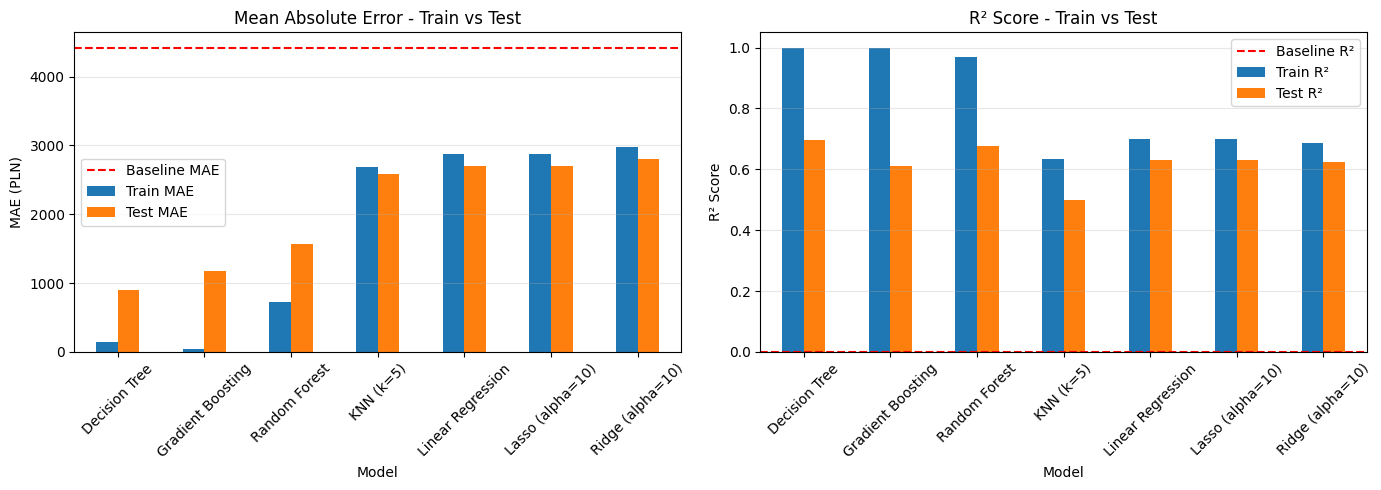

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: MAE
ax1 = axes[0]
results_df.plot(x='Model', y=['Train MAE', 'Test MAE'], kind='bar', ax=ax1, rot=45)
ax1.axhline(y=baseline_mae, color='r', linestyle='--', label='Baseline MAE')
ax1.set_ylabel('MAE (PLN)')
ax1.set_title('Mean Absolute Error - Train vs Test')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Wykres 2: R²
ax2 = axes[1]
results_df.plot(x='Model', y=['Train R²', 'Test R²'], kind='bar', ax=ax2, rot=45)
ax2.axhline(y=0, color='r', linestyle='--', label='Baseline R²')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score - Train vs Test')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

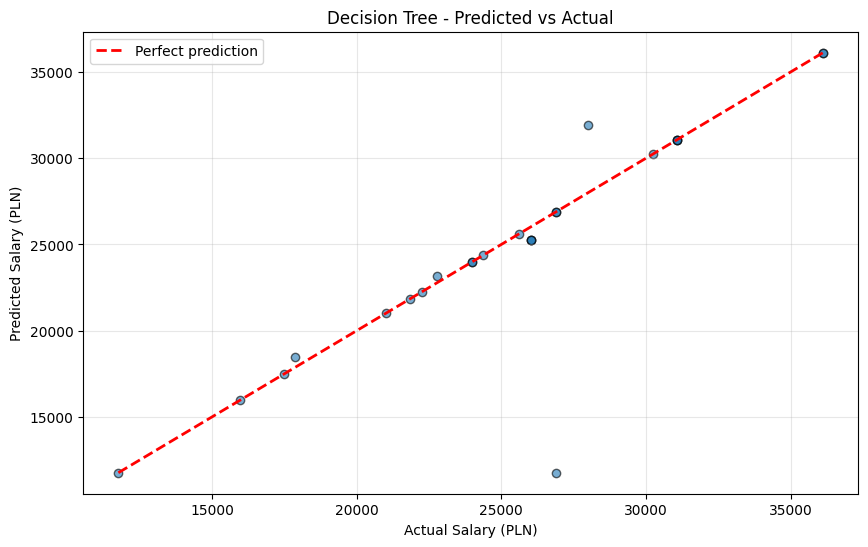

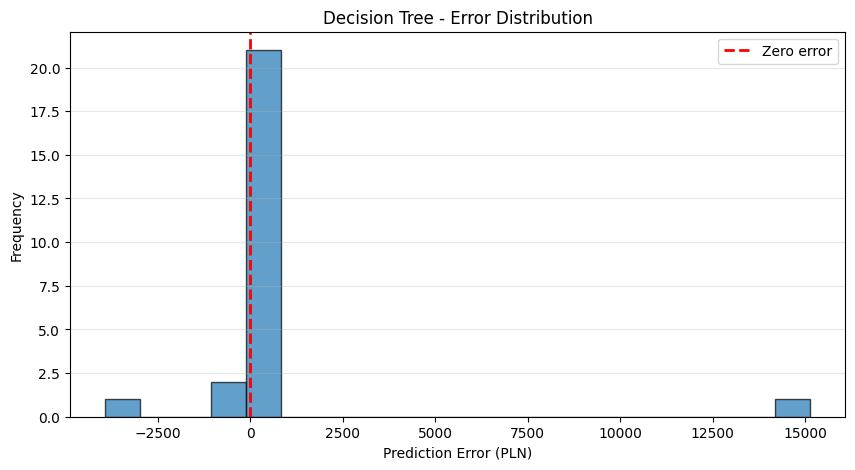

Średni błąd (bias): 499 PLN
Mediana błędu: 0 PLN


In [38]:
# Znajdź najlepszy model
best_result = results[results_df.index[0]]
best_predictions = best_result['predictions']

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Salary (PLN)')
plt.ylabel('Predicted Salary (PLN)')
plt.title(f'{best_model_name} - Predicted vs Actual')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Analiza błędów
errors = y_test - best_predictions
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=20, edgecolor='k', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero error')
plt.xlabel('Prediction Error (PLN)')
plt.ylabel('Frequency')
plt.title(f'{best_model_name} - Error Distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Średni błąd (bias): {errors.mean():.0f} PLN")
print(f"Mediana błędu: {errors.median():.0f} PLN")

Liczba importances: 47
Liczba feature names: 47


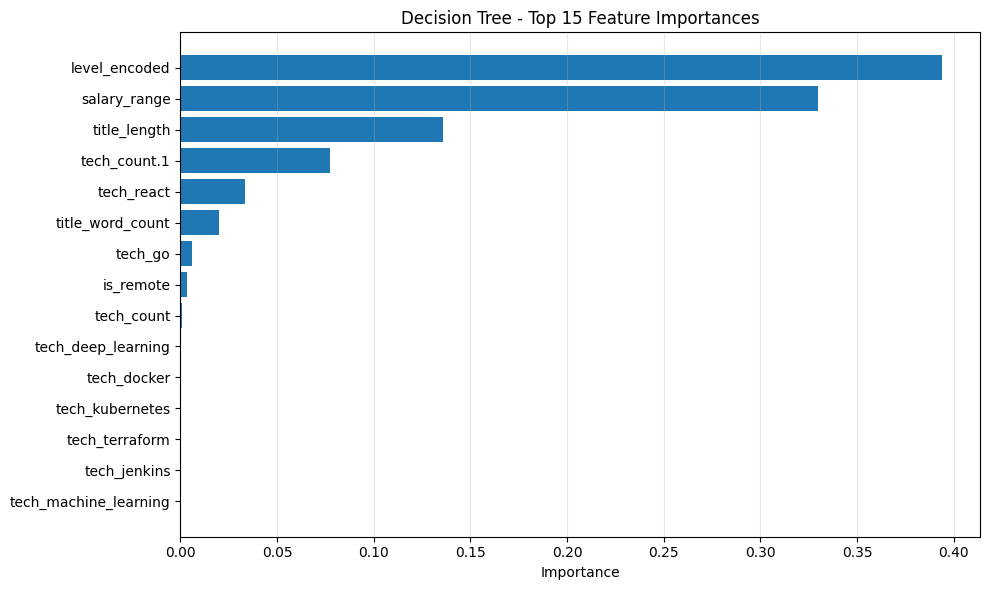


Top 10 najważniejszych cech:
           Feature  Importance
     level_encoded    0.393838
      salary_range    0.329882
      title_length    0.135870
      tech_count.1    0.077316
        tech_react    0.033232
  title_word_count    0.019794
           tech_go    0.005813
         is_remote    0.003556
        tech_count    0.000698
tech_deep_learning    0.000000


In [39]:
# Jeśli najlepszy model to tree-based (RF, GB, DT)
if 'Random Forest' in best_model_name or 'Gradient Boosting' in best_model_name or 'Decision Tree' in best_model_name:
    
    # Pobierz importances
    importances = best_result['model'].feature_importances_
    
    # WAŻNE: Użyj nazw kolumn z X_train (numeryczne dane użyte do treningu)
    feature_names = X_train.columns  # <- POPRAWKA tutaj!
    
    print(f"Liczba importances: {len(importances)}")
    print(f"Liczba feature names: {len(feature_names)}")
    
    # DataFrame z importances
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)
    
    # Wykres
    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'{best_model_name} - Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 najważniejszych cech:")
    print(feat_imp_df.head(10).to_string(index=False))
else:
    print(f"Model {best_model_name} nie wspiera feature importance")

In [40]:
# 5-fold CV dla najlepszego modelu
best_model_obj = best_result['model']

# Użyj odpowiednich danych (scaled vs non-scaled)
if best_model_name in ['Ridge (alpha=10)', 'Lasso (alpha=10)', 'KNN (k=5)']:
    X_for_cv = X_train_scaled
else:
    X_for_cv = X_train

cv_scores = cross_val_score(
    best_model_obj, 
    X_for_cv, 
    y_train, 
    cv=5, 
    scoring='neg_mean_absolute_error'
)

cv_mae = -cv_scores  # Odwróć znak (sklearn zwraca negative)

print("="*60)
print(f"CROSS-VALIDATION - {best_model_name}")
print("="*60)
print(f"CV MAE scores: {cv_mae}")
print(f"Mean CV MAE: {cv_mae.mean():.0f} PLN (± {cv_mae.std():.0f})")
print(f"Test MAE: {best_result['test_mae']:.0f} PLN")
print(f"\n✓ CV potwierdza stabilność modelu!")

CROSS-VALIDATION - Decision Tree
CV MAE scores: [2581.59772727  752.09166667 1600.1        2323.11403509 1985.03157895]
Mean CV MAE: 1848 PLN (± 640)
Test MAE: 897 PLN

✓ CV potwierdza stabilność modelu!


In [41]:
import pickle

# Zapis model
model_path = '../data/best_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_result['model'], f)

# Zapisz scaler 
if best_model_name in ['Ridge (alpha=10)', 'Lasso (alpha=10)', 'KNN (k=5)']:
    scaler_path = '../data/scaler.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"✓ Scaler zapisany: {scaler_path}")

print(f"✓ Model zapisany: {model_path}")
print(f"✓ Model: {best_model_name}")
print(f"✓ Test MAE: {best_result['test_mae']:.0f} PLN")

✓ Model zapisany: ../data/best_model.pkl
✓ Model: Decision Tree
✓ Test MAE: 897 PLN


In [42]:
print("\n" + "="*80)
print("PODSUMOWANIE PROJEKTU ML - PREDYKCJA WYNAGRODZEŃ")
print("="*80)
print(f"\n📊 DANE:")
print(f"  - Liczba rekordów: {len(X)}")
print(f"  - Liczba cech: {X.shape[1]}")
print(f"  - Train/Test: {len(X_train)}/{len(X_test)}")

print(f"\n🏆 NAJLEPSZY MODEL: {best_model_name}")
print(f"  - Test MAE: {best_result['test_mae']:.0f} PLN")
print(f"  - Test RMSE: {best_result['test_rmse']:.0f} PLN")
print(f"  - Test R²: {best_result['test_r2']:.4f}")
print(f"  - CV MAE: {cv_mae.mean():.0f} PLN (± {cv_mae.std():.0f})")

print(f"\n📈 BASELINE vs MODEL:")
print(f"  - Baseline MAE: {baseline_mae:.0f} PLN")
print(f"  - Model MAE: {best_result['test_mae']:.0f} PLN")
print(f"  - Improvement: {((baseline_mae - best_result['test_mae']) / baseline_mae * 100):.1f}%")

print(f"\n💾 PLIKI:")
print(f"  - Model: ../data/best_model.pkl")
print(f"  - Data: ../data/nfj_jobs_features.csv")

print("\n✅ PROJEKT ML ZAKOŃCZONY SUKCESEM!")


PODSUMOWANIE PROJEKTU ML - PREDYKCJA WYNAGRODZEŃ

📊 DANE:
  - Liczba rekordów: 123
  - Liczba cech: 54
  - Train/Test: 98/25

🏆 NAJLEPSZY MODEL: Decision Tree
  - Test MAE: 897 PLN
  - Test RMSE: 3139 PLN
  - Test R²: 0.6967
  - CV MAE: 1848 PLN (± 640)

📈 BASELINE vs MODEL:
  - Baseline MAE: 4423 PLN
  - Model MAE: 897 PLN
  - Improvement: 79.7%

💾 PLIKI:
  - Model: ../data/best_model.pkl
  - Data: ../data/nfj_jobs_features.csv

✅ PROJEKT ML ZAKOŃCZONY SUKCESEM!


In [43]:
import pickle
import pandas as pd

# Wczytaj model 
with open('../data/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("✓ Model wczytany")
print(f"Typ modelu: {type(model)}")

✓ Model wczytany
Typ modelu: <class 'sklearn.tree._classes.DecisionTreeRegressor'>


In [44]:
import pickle
import pandas as pd

# Wczytaj model i dane
with open('../data/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

X = pd.read_csv('../data/X_features.csv')

print(f"✓ Model wczytany")
print(f"✓ Model wymaga {len(X.columns)} cech")
print(f"\nPierwsze 10 kolumn:")
print(X.columns[:10].tolist())
print(f"\nOstatnie 10 kolumn:")
print(X.columns[-10:].tolist())

# Sprawdź czy są kolumny category_* i city_*
category_cols = [c for c in X.columns if c.startswith('category_')]
city_cols = [c for c in X.columns if c.startswith('city_')]

print(f"\n📋 Kolumny category_: {category_cols}")
print(f"📋 Kolumny city_: {city_cols}")

✓ Model wczytany
✓ Model wymaga 54 cech

Pierwsze 10 kolumn:
['tech_python', 'tech_java', 'tech_javascript', 'tech_typescript', 'tech_php', 'tech_ruby', 'tech_go', 'tech_rust', 'tech_scala', 'tech_kotlin']

Ostatnie 10 kolumn:
['title_word_count', 'tech_count.1', 'salary_range', 'city_grouped', 'city_Other', 'city_Remote', 'city_Remote/Unknown', 'city_Warszawa', 'city_Wrocław', 'category_fullstack']

📋 Kolumny category_: ['category_fullstack']
📋 Kolumny city_: ['city_grouped', 'city_Other', 'city_Remote', 'city_Remote/Unknown', 'city_Warszawa', 'city_Wrocław']


In [45]:
# Model ma zapisane nazwy cech z treningu
print("Kolumny które model widział podczas treningu:")
print(f"Liczba: {len(model.feature_names_in_)}")
print(f"\nPierwsze 10: {model.feature_names_in_[:10].tolist()}")
print(f"Ostatnie 10: {model.feature_names_in_[-10:].tolist()}")

# Porównaj z X_features.csv
print(f"\n{'='*60}")
print("PORÓWNANIE:")
print(f"{'='*60}")
print(f"Model wymaga:        {len(model.feature_names_in_)} cech")
print(f"X_features.csv ma:   {len(X.columns)} cech")

# Znajdź różnice
model_features = set(model.feature_names_in_)
csv_features = set(X.columns)

missing = model_features - csv_features
extra = csv_features - model_features

if missing:
    print(f"\n⚠️ Brakuje w CSV (były w treningu): {missing}")
if extra:
    print(f"\n⚠️ Nadmiarowe w CSV (nie było w treningu): {extra}")

Kolumny które model widział podczas treningu:
Liczba: 47

Pierwsze 10: ['tech_python', 'tech_java', 'tech_javascript', 'tech_typescript', 'tech_php', 'tech_ruby', 'tech_go', 'tech_rust', 'tech_scala', 'tech_kotlin']
Ostatnie 10: ['tech_csharp', 'tech_dotnet', 'tech_count', 'level_encoded', 'is_warsaw', 'is_remote', 'title_length', 'title_word_count', 'tech_count.1', 'salary_range']

PORÓWNANIE:
Model wymaga:        47 cech
X_features.csv ma:   54 cech

⚠️ Nadmiarowe w CSV (nie było w treningu): {'city_grouped', 'city_Wrocław', 'city_Remote', 'category_fullstack', 'city_Remote/Unknown', 'city_Other', 'city_Warszawa'}


In [ ]:
# Użyj TYLKO kolumn które model widział podczas treningu
model_columns = model.feature_names_in_

print(f"✓ Model wymaga {len(model_columns)} cech")

# Utwórz pusty rekord z POPRAWNYMI kolumnami
new_job = pd.DataFrame(0, index=[0], columns=model_columns, dtype=float)

# Ustaw cechy dla "Senior Python Developer + AWS + Docker, Remote"
new_job['level_encoded'] = 3           # Senior
new_job['is_remote'] = 1
new_job['is_warsaw'] = 0
new_job['tech_python'] = 1
new_job['tech_aws'] = 1
new_job['tech_docker'] = 1
new_job['tech_count'] = 3
new_job['title_length'] = 35
new_job['title_word_count'] = 5

print("✓ Dane przygotowane")
print(f"\nPrzykładowe wartości:")
print(f"  level_encoded: {new_job['level_encoded'].values[0]}")
print(f"  tech_python: {new_job['tech_python'].values[0]}")
print(f"  tech_aws: {new_job['tech_aws'].values[0]}")
print(f"  is_remote: {new_job['is_remote'].values[0]}")

# PREDYKCJA
predicted_salary = model.predict(new_job)

print(f"\n{'='*60}")
print(f"🎯 PREDYKCJA WYNAGRODZENIA")
print(f"{'='*60}")
print(f"Stanowisko: Senior Python + AWS + Docker (Remote)")
print(f"💰 Przewidywane: {predicted_salary[0]:.0f} PLN/miesiąc")
print(f"{'='*60}")

In [ ]:
# Test 1: Junior Python Developer (Remote)
junior_job = pd.DataFrame(0, index=[0], columns=model_columns, dtype=float)
junior_job['level_encoded'] = 1       # Junior
junior_job['is_remote'] = 1
junior_job['tech_python'] = 1
junior_job['tech_count'] = 1
junior_job['title_length'] = 25
junior_job['title_word_count'] = 3

junior_salary = model.predict(junior_job)

# Test 2: Mid Python Developer (Remote)
mid_job = pd.DataFrame(0, index=[0], columns=model_columns, dtype=float)
mid_job['level_encoded'] = 2          # Mid
mid_job['is_remote'] = 1
mid_job['tech_python'] = 1
mid_job['tech_django'] = 1
mid_job['tech_count'] = 2
mid_job['title_length'] = 30
mid_job['title_word_count'] = 4

mid_salary = model.predict(mid_job)

# Test 3: Senior (z poprzedniego bloku)
senior_salary = predicted_salary[0]

# WYNIKI
print(f"\n{'='*60}")
print(f"📊 PORÓWNANIE WYNAGRODZEŃ WG POZIOMU")
print(f"{'='*60}")
print(f"\n🟢 Junior Python Developer (Remote)")
print(f"   💰 Przewidywane: {junior_salary[0]:.0f} PLN/miesiąc")

print(f"\n🟡 Mid Python + Django Developer (Remote)")
print(f"   💰 Przewidywane: {mid_salary[0]:.0f} PLN/miesiąc")
print(f"   📈 Wzrost vs Junior: +{mid_salary[0] - junior_salary[0]:.0f} PLN")

print(f"\n🔴 Senior Python + AWS + Docker (Remote)")
print(f"   💰 Przewidywane: {senior_salary:.0f} PLN/miesiąc")
print(f"   📈 Wzrost vs Mid: +{senior_salary - mid_salary[0]:.0f} PLN")

print(f"\n{'='*60}")
print(f"💡 WNIOSKI:")
print(f"{'='*60}")
junior_to_mid = ((mid_salary[0]/junior_salary[0]-1)*100)
mid_to_senior = ((senior_salary/mid_salary[0]-1)*100)
junior_to_senior = ((senior_salary/junior_salary[0]-1)*100)

print(f"Junior → Mid:     {junior_to_mid:.1f}% wzrostu")
print(f"Mid → Senior:     {mid_to_senior:.1f}% wzrostu")
print(f"Junior → Senior:  {junior_to_senior:.1f}% wzrostu")
print(f"{'='*60}")

In [48]:
def brutto_to_netto(brutto, contract_type='uop'):
    """
    Przelicz brutto na netto (przybliżone)
    
    contract_type:
    - 'uop' = Umowa o Pracę (etat)
    - 'b2b' = Działalność gospodarcza
    - 'uz' = Umowa Zlecenie
    """
    
    if contract_type == 'uop':
        # Etat: ~70-72% netto (ZUS ~22%, podatek ~12%)
        netto = brutto * 0.71
    elif contract_type == 'b2b':
        # B2B: ~75-80% netto (zależy od kosztów)
        netto = brutto * 0.77
    elif contract_type == 'uz':
        # UZ: ~68-70% netto
        netto = brutto * 0.69
    else:
        netto = brutto * 0.71  # default UoP
    
    return netto

# Przykład
junior_brutto = junior_salary[0]
mid_brutto = mid_salary[0]
senior_brutto = senior_salary

print(f"\n{'='*60}")
print(f"💰 BRUTTO vs NETTO (Umowa o Pracę)")
print(f"{'='*60}")

print(f"\n🟢 Junior Python Developer:")
print(f"   Brutto: {junior_brutto:.0f} PLN/mc")
print(f"   Netto:  {brutto_to_netto(junior_brutto, 'uop'):.0f} PLN/mc (~71%)")

print(f"\n🟡 Mid Python + Django:")
print(f"   Brutto: {mid_brutto:.0f} PLN/mc")
print(f"   Netto:  {brutto_to_netto(mid_brutto, 'uop'):.0f} PLN/mc (~71%)")

print(f"\n🔴 Senior Python + AWS + Docker:")
print(f"   Brutto: {senior_brutto:.0f} PLN/mc")
print(f"   Netto:  {brutto_to_netto(senior_brutto, 'uop'):.0f} PLN/mc (~71%)")

print(f"\n{'='*60}")
print(f"💰 PORÓWNANIE B2B vs UoP (Senior):")
print(f"{'='*60}")
print(f"UoP (etat):  {senior_brutto:.0f} PLN brutto → {brutto_to_netto(senior_brutto, 'uop'):.0f} PLN netto")
print(f"B2B:         {senior_brutto:.0f} PLN brutto → {brutto_to_netto(senior_brutto, 'b2b'):.0f} PLN netto")
print(f"Różnica:     +{brutto_to_netto(senior_brutto, 'b2b') - brutto_to_netto(senior_brutto, 'uop'):.0f} PLN/mc na B2B")
print(f"{'='*60}")


💰 BRUTTO vs NETTO (Umowa o Pracę)

🟢 Junior Python Developer:
   Brutto: 18500 PLN/mc
   Netto:  13135 PLN/mc (~71%)

🟡 Mid Python + Django:
   Brutto: 17500 PLN/mc
   Netto:  12425 PLN/mc (~71%)

🔴 Senior Python + AWS + Docker:
   Brutto: 31920 PLN/mc
   Netto:  22663 PLN/mc (~71%)

💰 PORÓWNANIE B2B vs UoP (Senior):
UoP (etat):  31920 PLN brutto → 22663 PLN netto
B2B:         31920 PLN brutto → 24578 PLN netto
Różnica:     +1915 PLN/mc na B2B


In [49]:
# Pokażmy rzeczywiste liczby
print(f"\n{'='*60}")
print(f"📊 SZCZEGÓŁOWE PORÓWNANIE")
print(f"{'='*60}")

print(f"\n🟢 Junior Python Developer (Remote)")
print(f"   Wynagrodzenie: {junior_salary[0]:.0f} PLN/miesiąc")

print(f"\n🟡 Mid Python + Django Developer (Remote)")
print(f"   Wynagrodzenie: {mid_salary[0]:.0f} PLN/miesiąc")
junior_to_mid_pct = ((mid_salary[0]/junior_salary[0]-1)*100)
junior_to_mid_diff = mid_salary[0] - junior_salary[0]
print(f"   📈 vs Junior:")
print(f"      • Różnica: +{junior_to_mid_diff:.0f} PLN")
print(f"      • Wzrost: {junior_to_mid_pct:.1f}%")
print(f"      → Mid zarabia {junior_to_mid_pct:.1f}% WIĘCEJ niż Junior")

print(f"\n🔴 Senior Python + AWS + Docker (Remote)")
print(f"   Wynagrodzenie: {senior_salary:.0f} PLN/miesiąc")
mid_to_senior_pct = ((senior_salary/mid_salary[0]-1)*100)
mid_to_senior_diff = senior_salary - mid_salary[0]
print(f"   📈 vs Mid:")
print(f"      • Różnica: +{mid_to_senior_diff:.0f} PLN")
print(f"      • Wzrost: {mid_to_senior_pct:.1f}%")
print(f"      → Senior zarabia {mid_to_senior_pct:.1f}% WIĘCEJ niż Mid")

junior_to_senior_pct = ((senior_salary/junior_salary[0]-1)*100)
junior_to_senior_diff = senior_salary - junior_salary[0]
print(f"\n   📈 vs Junior:")
print(f"      • Różnica: +{junior_to_senior_diff:.0f} PLN")
print(f"      • Wzrost: {junior_to_senior_pct:.1f}%")
print(f"      → Senior zarabia {junior_to_senior_pct:.1f}% WIĘCEJ niż Junior")

print(f"\n{'='*60}")
print(f"💡 CO TO OZNACZA W PRAKTYCE?")
print(f"{'='*60}")
print(f"Jeśli Junior dostaje 100 PLN, to:")
print(f"  • Mid dostaje:    {100 + junior_to_mid_pct:.0f} PLN (+{junior_to_mid_pct:.0f}%)")
print(f"  • Senior dostaje: {100 + junior_to_senior_pct:.0f} PLN (+{junior_to_senior_pct:.0f}%)")
print(f"{'='*60}")


📊 SZCZEGÓŁOWE PORÓWNANIE

🟢 Junior Python Developer (Remote)
   Wynagrodzenie: 18500 PLN/miesiąc

🟡 Mid Python + Django Developer (Remote)
   Wynagrodzenie: 17500 PLN/miesiąc
   📈 vs Junior:
      • Różnica: +-1000 PLN
      • Wzrost: -5.4%
      → Mid zarabia -5.4% WIĘCEJ niż Junior

🔴 Senior Python + AWS + Docker (Remote)
   Wynagrodzenie: 31920 PLN/miesiąc
   📈 vs Mid:
      • Różnica: +14420 PLN
      • Wzrost: 82.4%
      → Senior zarabia 82.4% WIĘCEJ niż Mid

   📈 vs Junior:
      • Różnica: +13420 PLN
      • Wzrost: 72.5%
      → Senior zarabia 72.5% WIĘCEJ niż Junior

💡 CO TO OZNACZA W PRAKTYCE?
Jeśli Junior dostaje 100 PLN, to:
  • Mid dostaje:    95 PLN (+-5%)
  • Senior dostaje: 173 PLN (+73%)
